In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.naive_bayes import CategoricalNB
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    ConfusionMatrixDisplay
)

In [2]:
from google.colab import files

uploaded = files.upload()  # selecione o arquivo .xlsx
filename = list(uploaded.keys())[0]

df = pd.read_excel(filename)
print(f'Shape: {df.shape}')
df.head()

Saving Inteligência Artificial - Base Gripe (respostas).xlsx to Inteligência Artificial - Base Gripe (respostas).xlsx
Shape: (186, 11)


,Carimbo de data/hora,Você ficou gripado no ano passado ?,Você tomou vacina da gripe no ano passado?,"Você frequentou no ano passado, semanalmente ambientes com muitas pessoas? (salas cheias, ônibus, eventos, etc.)",Você viajou no ano passado mais de 100 km de distância?,"Você tem alergia nas vias aéreas (rinite, sinusite, etc.)?",Quantas horas você dormiu em média por noite no ano passado?,Você praticou atividade física no ano passado?,Você se alimentou de forma balanceada no ano passado?,"Em média, quantas vezes você lavou as mãos por dia no ano passado?","Na sua percepção, o seu nível de estresse no ano passado foi:"
0,2026-03-24 15:01:34.703,Sim,Sim,Sim,Poucas vezes por ano,Médio,4 horas ou menos,Sim,Às vezes,3 a 5 vezes,5.0
1,2026-03-24 15:04:19.657,Sim,Sim,Sim,Nuca,Não,entre 4 e 6 horas,Não,"Não, raramente",Mais de 10 vezes,3.0
2,2026-03-24 15:04:19.758,Sim,Não,Sim,Poucas vezes por ano,Pouco,mais de 6 horas,Sim,Às vezes,6 a 10 vezes,3.0
3,2026-03-24 15:04:37.421,Sim,Não,Não,Nuca,Muito,mais de 6 horas,Sim,Às vezes,2 vezes ou menos,2.0
4,2026-03-24 15:05:27.378,Sim,Sim,Sim,Pelo menos uma vez por mês,Médio,entre 4 e 6 horas,Não,Às vezes,6 a 10 vezes,4.0


In [3]:
# Remover coluna de timestamp
df = df.drop(columns=['Carimbo de data/hora'])

# Renomear colunas para nomes curtos
df.columns = [
    'Gripado', 'Vacina', 'AmbientesCheios', 'Viajou',
    'Alergia', 'HorasSono', 'AtividadeFisica', 'Alimentacao',
    'LavouMaos', 'Estresse'
]

# Discretizar Estresse (era numérico 1-5) em categorias
df['Estresse'] = df['Estresse'].fillna(df['Estresse'].median())
df['Estresse'] = df['Estresse'].apply(
    lambda x: 'Baixo' if x <= 2 else ('Médio' if x <= 3 else 'Alto')
)

print('Distribuição da classe alvo:')
print(df['Gripado'].value_counts())
print(f'\nValores nulos: {df.isnull().sum().sum()}')
df.head()

Distribuição da classe alvo:
Gripado
Sim    109
Não     77
Name: count, dtype: int64

Valores nulos: 0


,Gripado,Vacina,AmbientesCheios,Viajou,Alergia,HorasSono,AtividadeFisica,Alimentacao,LavouMaos,Estresse
0,Sim,Sim,Sim,Poucas vezes por ano,Médio,4 horas ou menos,Sim,Às vezes,3 a 5 vezes,Alto
1,Sim,Sim,Sim,Nuca,Não,entre 4 e 6 horas,Não,"Não, raramente",Mais de 10 vezes,Médio
2,Sim,Não,Sim,Poucas vezes por ano,Pouco,mais de 6 horas,Sim,Às vezes,6 a 10 vezes,Médio
3,Sim,Não,Não,Nuca,Muito,mais de 6 horas,Sim,Às vezes,2 vezes ou menos,Baixo
4,Sim,Sim,Sim,Pelo menos uma vez por mês,Médio,entre 4 e 6 horas,Não,Às vezes,6 a 10 vezes,Alto


In [4]:
encoders = {}
df_enc = df.copy()

for col in df.columns:
    le = LabelEncoder()
    df_enc[col] = le.fit_transform(df[col])
    encoders[col] = le
    print(f'{col}: {list(le.classes_)}')

Gripado: ['Não', 'Sim']
Vacina: ['Não', 'Sim']
AmbientesCheios: ['Não', 'Sim']
Viajou: ['Nuca', 'Pelo menos uma vez por mês', 'Poucas vezes por ano']
Alergia: ['Muito', 'Médio', 'Não', 'Pouco']
HorasSono: ['4 horas ou menos', 'entre 4 e 6 horas', 'mais de 6 horas']
AtividadeFisica: ['Não', 'Sim']
Alimentacao: ['Não, raramente', 'Sim, a maior parte do tempo', 'Às vezes']
LavouMaos: ['2 vezes ou menos', '3 a 5 vezes', '6 a 10 vezes', 'Mais de 10 vezes']
Estresse: ['Alto', 'Baixo', 'Médio']


In [5]:
X = df_enc.drop('Gripado', axis=1)
y = df_enc['Gripado']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Treino: {len(X_train)} amostras')
print(f'Teste:  {len(X_test)} amostras')

Treino: 148 amostras
Teste:  38 amostras


In [6]:
model = CategoricalNB()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
cv_scores = cross_val_score(model, X, y, cv=5)

print(f'Acurácia no teste:        {acc*100:.2f}%')
print(f'Validação cruzada 5-fold: {cv_scores.mean()*100:.2f}% ± {cv_scores.std()*100:.2f}%')

Acurácia no teste:        63.16%
Validação cruzada 5-fold: 55.93% ± 6.38%


In [7]:
target_names = encoders['Gripado'].classes_
print(classification_report(y_test, y_pred, target_names=target_names))

              precision    recall  f1-score   support

         Não       0.62      0.31      0.42        16
         Sim       0.63      0.86      0.73        22

    accuracy                           0.63        38
   macro avg       0.63      0.59      0.57        38
weighted avg       0.63      0.63      0.60        38



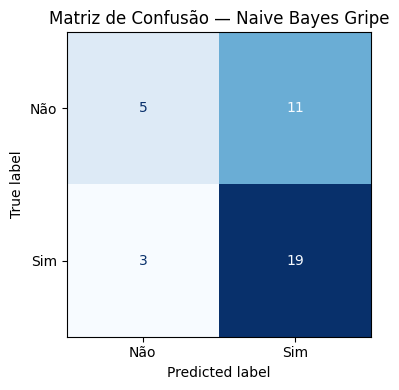

In [8]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Matriz de Confusão — Naive Bayes Gripe')
plt.tight_layout()
plt.show()

In [9]:
print('Probabilidades a priori P(classe):')
for i, cls in enumerate(target_names):
    prob = np.exp(model.class_log_prior_[i])
    print(f'  P({cls} gripado) = {prob:.4f}  ({prob*100:.1f}%)')

Probabilidades a priori P(classe):
  P(Não gripado) = 0.4122  (41.2%)
  P(Sim gripado) = 0.5878  (58.8%)


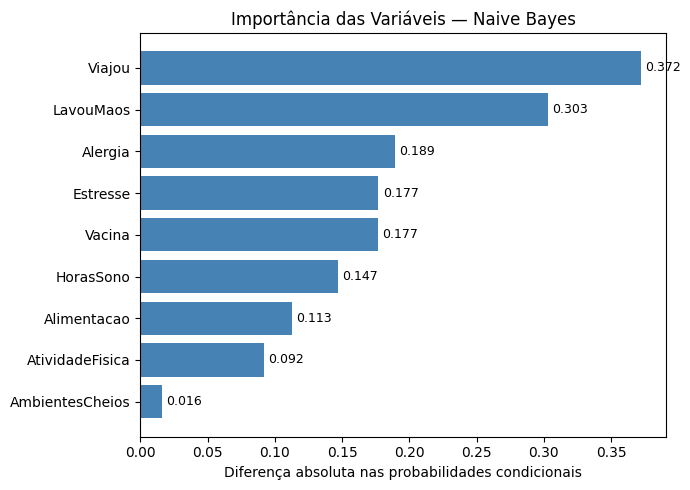

In [10]:
feat_names = list(X.columns)
importances = []

for j, fname in enumerate(feat_names):
    arr = model.feature_log_prob_[j]  # shape (n_classes, n_categorias)
    probs_nao = np.exp(arr[0])
    probs_sim = np.exp(arr[1])
    diff = np.sum(np.abs(probs_nao - probs_sim))
    importances.append((fname, diff))

importances.sort(key=lambda x: x[1])
labels, vals = zip(*importances)

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.barh(labels, vals, color='steelblue')
ax.set_xlabel('Diferença absoluta nas probabilidades condicionais')
ax.set_title('Importância das Variáveis — Naive Bayes')
ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=9)
plt.tight_layout()
plt.show()

In [11]:
# Edite os valores abaixo para testar um novo paciente
novo_paciente = {
    'Vacina':           'Sim',              # 'Sim' ou 'Não'
    'AmbientesCheios':  'Sim',              # 'Sim' ou 'Não'
    'Viajou':           'Poucas vezes por ano',  # 'Nuca', 'Poucas vezes por ano', 'Pelo menos uma vez por mês'
    'Alergia':          'Pouco',            # 'Não', 'Pouco', 'Médio', 'Muito'
    'HorasSono':        'mais de 6 horas',  # '4 horas ou menos', 'entre 4 e 6 horas', 'mais de 6 horas'
    'AtividadeFisica':  'Sim',              # 'Sim' ou 'Não'
    'Alimentacao':      'Às vezes',         # 'Não, raramente', 'Às vezes', 'Sim, a maior parte do tempo'
    'LavouMaos':        '6 a 10 vezes',     # '2 vezes ou menos', '3 a 5 vezes', '6 a 10 vezes', 'Mais de 10 vezes'
    'Estresse':         'Médio',            # 'Baixo', 'Médio', 'Alto'
}

# Codificar o novo paciente
paciente_enc = []
for col, val in novo_paciente.items():
    paciente_enc.append(encoders[col].transform([val])[0])

paciente_arr = np.array(paciente_enc).reshape(1, -1)

pred_class = encoders['Gripado'].classes_[model.predict(paciente_arr)[0]]
probs = model.predict_proba(paciente_arr)[0]

print('=== Resultado da Predição ===')
print(f'Predição:         {pred_class}')
for i, cls in enumerate(encoders['Gripado'].classes_):
    print(f'P({cls} gripado) = {probs[i]:.4f} ({probs[i]*100:.1f}%)')

=== Resultado da Predição ===
Predição:         Sim
P(Não gripado) = 0.4195 (42.0%)
P(Sim gripado) = 0.5805 (58.0%)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but CategoricalNB was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but CategoricalNB was fitted with feature names
  warnings.warn(
